In [9]:
import discovery as ds
import jax
import discovery.samplers.numpyro as ds_numpyro
from matplotlib import pyplot as plt
import corner

In [10]:
import importlib
importlib.reload(ds.signals)
importlib.reload(ds.pulsar)
importlib.reload(ds.deterministic)
importlib.reload(ds.matrix)
importlib.reload(ds)

<module 'discovery' from '/home/abhimanyu/Work/discovery/src/discovery/__init__.py'>

In [35]:
ds.prior.priordict_standard.update({
    "(.*_)?test_log10_A": [-9, -4],
    "(.*_)?test_log10_f": [-9, -6],
    "(.*_)?test_phi0": [0, 2 * jax.numpy.pi],
})

In [36]:
psr = ds.Pulsar.read_feather("sim1.feather")

In [37]:
t0 = min(psr.toas)
def test_delay(toas, log10_A, log10_f, phi0):
    omega = 2 * jax.numpy.pi * (10**log10_f)
    A = 10**log10_A
    phi = omega*(toas - t0) + phi0
    return A*jax.numpy.cos(phi)

In [38]:
noisedict = {'SIM1_efac': 1.5, 'SIM1_log10_t2equad': -5.96}

In [47]:
signals = [
    psr.residuals,                                                  # Data vector
    ds.makenoise_measurement_simple(psr, noisedict=noisedict),      # White noise (EFAC/EQUAD)
    ds.makegp_timing(psr),                                          # Timing model
    ds.makedelay(psr, test_delay, name="test"),
]

In [48]:
psl = ds.PulsarLikelihood(signals)

In [49]:
psl.logL.params

['SIM1_test_log10_A', 'SIM1_test_log10_f', 'SIM1_test_phi0']

In [50]:
p0 = ds.sample_uniform(psl.logL.params)
psl.logL(p0), jax.grad(psl.logL)(p0)

(Array(23679.21701762, dtype=float64),
 {'SIM1_test_log10_A': Array(-3600.84482093, dtype=float64, weak_type=True),
  'SIM1_test_log10_f': Array(68693.29976743, dtype=float64, weak_type=True),
  'SIM1_test_phi0': Array(69.92047931, dtype=float64, weak_type=True)})

In [61]:
npmodel = ds_numpyro.makemodel_transformed(psl.logL)
npsampler = ds_numpyro.makesampler_nuts(npmodel, num_warmup=5000, num_samples=10000)

In [62]:
npsampler.run(jax.random.PRNGKey(101))

sample: 100%|██████████| 15000/15000 [01:31<00:00, 164.30it/s, 31 steps of size 6.63e-02. acc. prob=0.48] 


In [63]:
chain = npsampler.to_df()

In [64]:
# plt.plot(chain["SIM1_efac"].array)

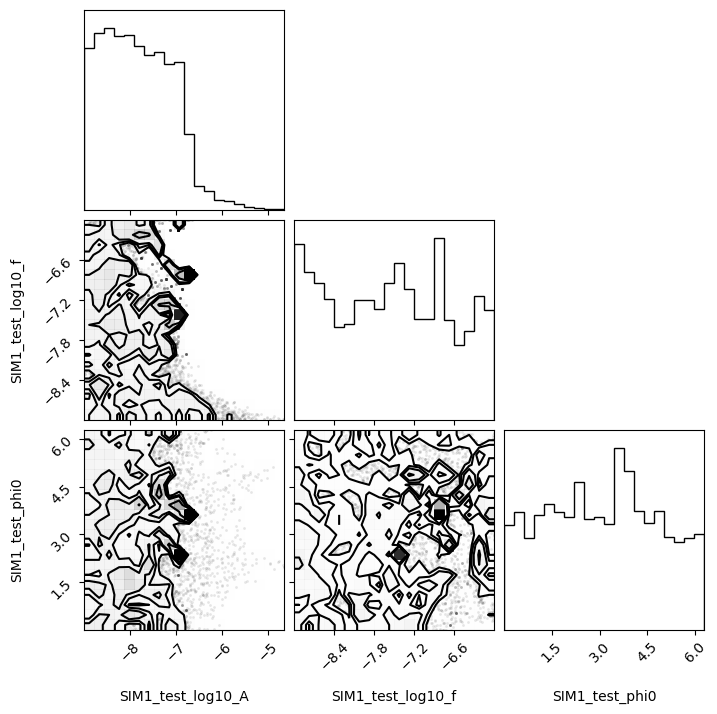

In [65]:
corner.corner(chain.to_numpy(), labels=psl.logL.params);